### Author: Maake Masekela Isaac 
>**Aspiring AI Engineer (Agents | LLM's)**
###### Kaggle:   [Kaggle](https://www.kaggle.com/masekelaisaacmaake)
###### Github:   [Github](https://github.com/Isaacdvs2)
###### LinkedIn: [LinkedIn](https://www.linkedin.com/in/isaac-maake-198910/)


### Introduction
The purpose of this notebook is to create a model that can classify messages as ham or spam, and to understand the patterns that distinguishes them.

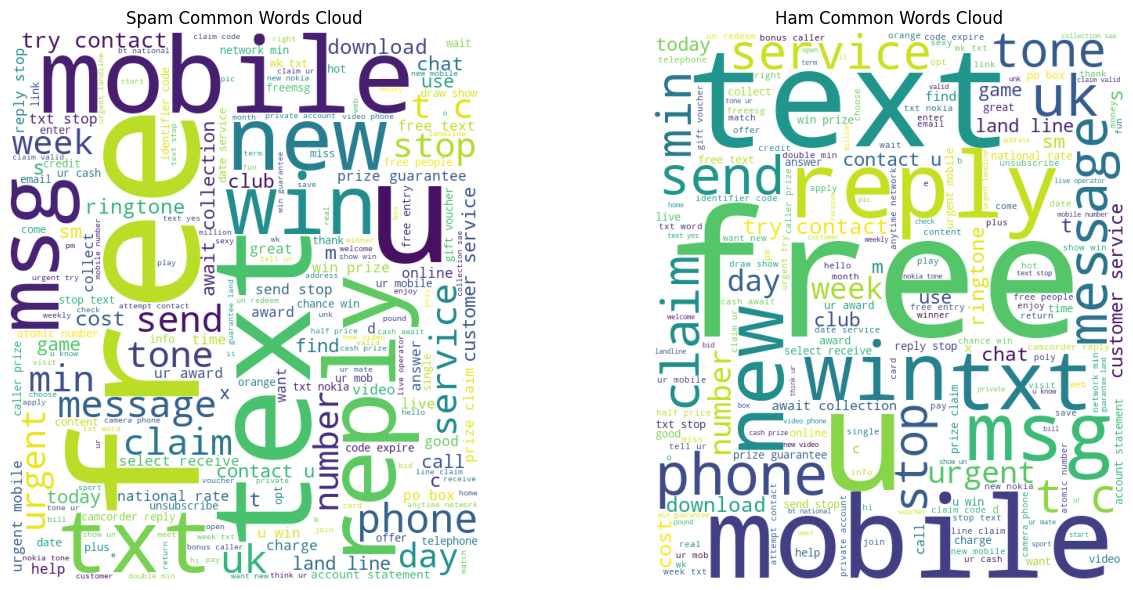

#### Objectives
* Build multiple classification model to distinguish spam from ham
* Engineer meaningful features (e.g., message length, presence of numbers and URLs)
* Augment the data to create new data from the existing data 
* Analyse the to help us see more into the data
* Perform Vectorization on the data to convert text into numbers so that a model can understand it
* Create and compare multiple machine learning models and evaluate their performance


#### Data
This notebook uses the practice datasets found on Kaggle: [Get the dataset here.](https://www.kaggle.com/datasets/ajaytony45/sms-spam)

**NLP?**
Is a field that combines linguistics and AI to enable computers to process and understand human language.

To get all the libraries used in this notebook, run the next cell and open the created requirements text file in the project directory.



In [ ]:
# get all the required libraries to run the notebook
!pip freeze > requirements.txt

### 1. Import the Libraries / Modules, that will help achieve the desired goal

In [27]:
# import the base libraries for loading data and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#view the graphs inline
%matplotlib inline              

# We will use the industry standard lib
import spacy

# import the sklearn functions useful for NLP
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline




#### 2. Data Collection And Exploration

In [2]:
# Load the data
sms_data = pd.read_csv('../datasets/spam.csv', encoding='latin-1')

In [ ]:
# View the data info and the first 5 columns
sms_data.info()
sms_data.head()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5169 non-null   int64
 1   message  5169 non-null   str  
dtypes: int64(1), str(1)
memory usage: 121.1 KB


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


**Observations**
* The data has the label column named as v1 and the features column as v2. The rest of the columns are unnamed.
* The Unnamed columns have many missing values and will not contribute to the goal of this project and will be removed. V2 and v1 columns have no missing values and will be kept.
* The data contains 5169 total rows.
* The label column's data type is integer whilst the rest are of type string

In [3]:
# remove the unneccesary columns and rename the remaining columns to something meaningful
sms_data = sms_data[['v1', 'v2']]
sms_data.columns = ['label', 'message']
sms_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Since our goal is to classify the messages, lets convert the labels: ham = 0 and spam = 1 

In [4]:
# convert the label column to binary values
sms_data['label'] = sms_data['label'].map({'ham': 0, 'spam': 1})
# verify
sms_data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#Check for number of dupplicates
print("Number of duplicates: ", sms_data.duplicated().sum())

# View the top 10 duplicates, sort them so that duplicates are together. Note "keep=False" -
# makes sure we return both the 1st and 2nd duplicate. 
sms_data[sms_data['message'].duplicated(keep=False)].sort_values(by='message').head(10)


Number of duplicates:  403


,label,message
504,1,+123 Congratulations - in this week's competit...
2123,1,+123 Congratulations - in this week's competit...
2343,0,1) Go to write msg 2) Put on Dictionary mode 3...
1372,0,1) Go to write msg 2) Put on Dictionary mode 3...
2162,0,1) Go to write msg 2) Put on Dictionary mode 3...
1049,1,18 days to Euro2004 kickoff! U will be kept in...
2718,1,18 days to Euro2004 kickoff! U will be kept in...
2043,1,4mths half price Orange line rental & latest c...
388,1,4mths half price Orange line rental & latest c...
1778,0,7 wonders in My WORLD 7th You 6th Ur style 5th...


**Dealing with Duplicates**
* Impact of duplicates on the goal: A model does not learn anything new from duplicate entries.
* Resolution: remove(drop) the duplicates from the data

In [5]:
# Remove the duplicates 
sms_data = sms_data.drop_duplicates()

#verify the removal
sms_data[sms_data['message'].duplicated(keep=False)].sort_values(by='message').head(10)


,label,message


The count of Spam and ham rows from the data
label
0    4516
1     653
Name: count, dtype: int64


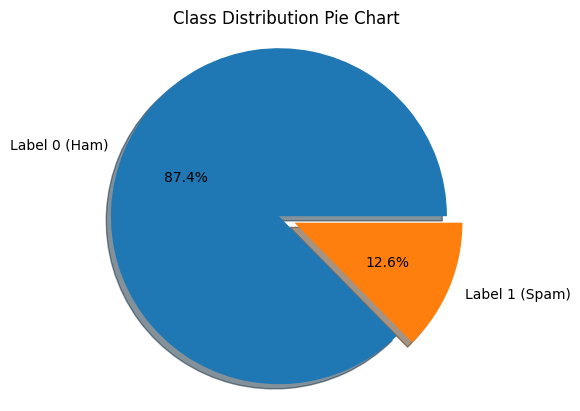

In [6]:
#Check the class Distribution -> Check the data balance, you dont want 
# a certain feature to have more examples than the other as this will cause
# the model to learn those features only. 
print("The count of Spam and ham rows from the data")
print(sms_data['label'].value_counts())

# make sense of the info in a pie chart
explode = (0.1,0)
plt.pie(sms_data['label'].value_counts(), explode = explode,
        labels=['Label 0 (Ham)', 'Label 1 (Spam)'], 
        autopct='%1.1f%%', shadow=True)
plt.axis('equal')
plt.title("Class Distribution Pie Chart")
plt.show()


From the class distribution, we have roughly 87% ham and 13%spam. If we continue with the data as it is, it will influence the model to overfit the data, and especially when it comes to detecting spam -- as there isn't enough examples for spam especially when we will split the data for training and testing. 
* Imbalance means the model sees one class much more, it becomes biased toward it.

There are some techniques we can employ to address the issue which fall into two stages, Pre-Training and Post-Training:
* Pre-Training: This is where we deal with the issue before training the model using techniques such as oversampling.
    * **Oversampling** - the idea is to duplicate the imbalanced variable (spam messages) to balance the data.
    * **Undersampling** - downsize the other variable(s) (ham messages) to match the imbalanced one
    * Apply the **SMOTE** technique - this technique helps us with generating synthetic examples(data) for the imbalanced data. This technique is *applied after splitting the data into training and test set*. SMOTE creates new minority samples by interpolating between similar existing ones, not by copying, hence it can work but is not always ideal for NLP, because SMOTE works best with continuous numeric data, NLP vectors are sparse and discrete.
    * Use **Class Weights**: Simply tell the model which variable is more important. Note that Naive Bayes doesnt directly support class weights, but other models do.
    * Apply a **Text Augmentation Technique**: With help from libraries such as nlpaug, EDA, and TextAttack, to name a few, we can augment the data. So instead of duplicating or reducing the data, or creating fake numeric vectors, we create new text samples by slightly modifying real text. 
        * Consider the sentence "win a free prize now". It can be augmented into one of the following: "win a free reward now", "get a free prize now", and "win a free prize today".
        * Augmentation techniques include synonym replacement, contextual augmentation, random insertion, random swap, and random deletion to name a few.
* Post-Training: This is where we deal with the issue after or during the training of the model using better evaluation metrics.
    * Precision → “When I predict spam, how often am I right?”
    * Recall → “How many spam messages did I catch?”
    * F1-score → Balance of both -> did I classify both spam and ham correctly?

All these methods for dealing with the imbalanced data can be explored and one can determine how they impact data and the model. I will proceed with the nlpaug library to generate meaningful data with real sentences by applying contextual augmentation to take advantage of the recent powerful tech -- Why not?!

We will use the nlpaug library to augment the data in 3 ways: Synonym (lexical variation), contexxtual substitute (smarter word replacements), and contextual insert (adds realism)

In [7]:
# import the nlpaug augmenter
import nlpaug.augmenter.word as naw

c:\Users\Isaac Maake\Documents\Projects\AIE\Data-Science-AI-ML-\NLP\nlpEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# apply only to the spam features (separate spam and ham)
spam_df = sms_data[sms_data['label'] == 1].copy()
ham_df = sms_data[sms_data['label'] == 0].copy()

In [9]:
# initialise the augmenters
aug_syn = naw.SynonymAug(aug_src='wordnet')
aug_context_sub = naw.ContextualWordEmbsAug(
    model_path='bert-base-uncased',
    action="substitute"
)

aug_context_ins = naw.ContextualWordEmbsAug(
    model_path='bert-base-uncased',
    action="insert"
)

augmenters = [aug_syn, aug_context_sub, aug_context_ins]

# Create a function to apply the augmentation with a fallback logic if augmentation fails

def augment_text(text, n_aug=3):
    augmented_texts = []
    
    for aug in augmenters:
        try:
            aug_result = aug.augment(text)
            
            # Ensure output is always a list
            if isinstance(aug_result, list):
                augmented_texts.extend(aug_result)
            else:
                augmented_texts.append(aug_result)
                
        except:
            continue  # skip failed augmenter

    # Limit number of augmentations per sample
    return augmented_texts[:n_aug]

# Apply the augmentation
augmented_rows = []

for _, row in spam_df.iterrows():
    text = row['message']
    label = row['label']
    
    augmented_texts = augment_text(text)
    
    for aug_text in augmented_texts:
        augmented_rows.append({
            'label': label,
            'message': aug_text
        })

# Create the augmented dataframe
aug_spam_df = pd.DataFrame(augmented_rows)

# Combine the data
sms_augmented = pd.concat([
    ham_df[['label', 'message']],
    spam_df[['label', 'message']],   # original spam
    aug_spam_df                      # augmented spam
], ignore_index=True)

# Shuffle the data
sms_augmented = sms_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

c:\Users\Isaac Maake\Documents\Projects\AIE\Data-Science-AI-ML-\NLP\nlpEnv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [10]:
# assess
print(sms_augmented.info())
sms_augmented.head()

<class 'pandas.DataFrame'>
RangeIndex: 7128 entries, 0 to 7127
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    7128 non-null   int64
 1   message  7128 non-null   str  
dtypes: int64(1), str(1)
memory usage: 111.5 KB
None


,label,message
0,0,and picking them up from various points
1,0,I get out of class in bsn in like &lt;#&gt; ...
2,1,hold urgent! as your mobile number has previou...
3,1,YOU take in WON! As a valued Vodafone client o...
4,0,Den wat will e schedule b lk on sun?


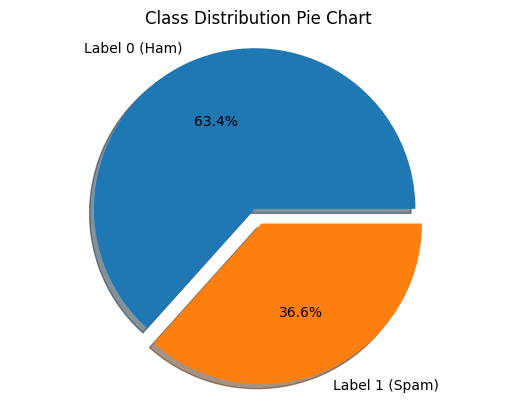

In [11]:
# make sense of the info in a pie chart again
explode = (0.1,0)
plt.pie(sms_augmented['label'].value_counts(), explode = explode,
        labels=['Label 0 (Ham)', 'Label 1 (Spam)'], 
        autopct='%1.1f%%', shadow=True)
plt.axis('equal')
plt.title("Class Distribution Pie Chart")
plt.show()

In [ ]:
# Save the data to avoid repeating some steps above that take longer to augment the data
sms_augmented.to_csv('../datasets/sms_messages_v2', index = False)

In [ ]:
# Load the new data to continue from here to avoid starting over if the kernel is 
# restarted or pc crashed
sms_aug = pd.read_csv('../datasets/sms_messages_v2', encoding='latin-1')

In [14]:
# data info
sms_aug.info()
sms_aug.head()

<class 'pandas.DataFrame'>
RangeIndex: 7128 entries, 0 to 7127
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    7128 non-null   int64
 1   message  7128 non-null   str  
dtypes: int64(1), str(1)
memory usage: 111.5 KB


,label,message
0,0,and picking them up from various points
1,0,I get out of class in bsn in like &lt;#&gt; ...
2,1,hold urgent! as your mobile number has previou...
3,1,YOU take in WON! As a valued Vodafone client o...
4,0,Den wat will e schedule b lk on sun?


The dataset is now moderately imbalanced, but with enough examples for spam. We will deal with this imbalance later when we implement the model.
Lets understand the data a bit more:

    * We need to know what distinguishes spam from ham in terms of features. This may allow us to come up with even more features that will allow us to train a good model.

    * Spam : a message that seems suspicious, convincing and too good to be true. Usually include currencies, URL's, prizes, words like "Congratulations", and the text is usually longer. These type of messages usually aim to get the user to perform a task for a reward.

    * Ham : a normal message without any intention to guide the user to perform a certain task for a reward.

So we will analyse the data for word counts, word frequency, sentence length, URLs', phone numbers etc. These are features that can help us understand the data better and guide our model selection decisions

In [15]:
# Add features: character length, word count, whether or not the message has 
# numbers(currency), whether or not a URL is present

sms_aug['char_length'] = sms_aug['message'].apply(len)
sms_aug['word_count'] = sms_aug['message'].apply(lambda x: len(x.split()))

#check if a message has a url and numbers (currency, phone numbers) using regex
import re

def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

def has_meaningful_numbers(text):
    text = remove_urls(text)
    return bool(re.search(r'\d{3,}(\.\d+)?', text))
# apply to the augmented data 
sms_aug['has_number'] = sms_aug['message'].apply(has_meaningful_numbers)
sms_aug['has_number'] = sms_aug['message'].apply(has_meaningful_numbers).astype(int)



# create the has_url column
def has_url(text):
    pattern = r'http[s]?://|www\.'
    return 1 if re.search(pattern, text) else 0

sms_aug['has_url'] = sms_aug['message'].apply(has_url)


# verify
sms_aug.info()
sms_aug.head()


<class 'pandas.DataFrame'>
RangeIndex: 7128 entries, 0 to 7127
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   label        7128 non-null   int64
 1   message      7128 non-null   str  
 2   char_length  7128 non-null   int64
 3   word_count   7128 non-null   int64
 4   has_number   7128 non-null   int64
 5   has_url      7128 non-null   int64
dtypes: int64(5), str(1)
memory usage: 334.2 KB


,label,message,char_length,word_count,has_number,has_url
0,0,and picking them up from various points,41,7,0,0
1,0,I get out of class in bsn in like &lt;#&gt; ...,82,16,0,0
2,1,hold urgent! as your mobile number has previou...,200,33,1,0
3,1,YOU take in WON! As a valued Vodafone client o...,138,28,1,0
4,0,Den wat will e schedule b lk on sun?,36,9,0,0


The function above to check for the numbers (currencies, ..etc,.) has been created to search atleast 3 digits in a row including those with a decimal. This is so that we check for currencies (as a lot of spam contains currency and phone numbers) excluding numbers in urls.

In [ ]:
# Our next goal is to view the common words for each message type. 1st The data has to be 
# cleaned by lemmatizind and removal of the stop words.

# Use the Spacy library for this purpose as it is more accurate and modern. 
# It is context aware and handles grammar better
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    # Handle bad inputs
    if not isinstance(text, str):
        text = str(text)

    doc = nlp(text.lower())

    words= [
            token.lemma_
            for token in doc 
            if token.is_alpha and not token.is_stop
        ]
    return " ".join(words)

# Apply preprocessing
sms_aug['clean_message'] = sms_aug['message'].apply(preprocess)

#lets keep only the meaningful columns
sms_aug = sms_aug[['label', 'clean_message', 'char_length',
                    'word_count','has_number', 'has_url']]
# Verify
sms_aug.info()
sms_aug.head()


<class 'pandas.DataFrame'>
RangeIndex: 7128 entries, 0 to 7127
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   label          7128 non-null   int64
 1   clean_message  7128 non-null   str  
 2   char_length    7128 non-null   int64
 3   word_count     7128 non-null   int64
 4   has_number     7128 non-null   int64
 5   has_url        7128 non-null   int64
dtypes: int64(5), str(1)
memory usage: 334.2 KB


,label,clean_message,char_length,word_count,has_number,has_url
0,0,pick point,41,7,0,0
1,0,class bsn like minute know advise,82,16,0,0
2,1,hold urgent mobile number previously award pri...,200,33,1,0
3,1,won value vodafone client computer cull win pr...,138,28,1,0
4,0,den wat e schedule b lk sun,36,9,0,0


Notice that the libraries do not understand the context of messages written in the modern style e.g If I was u, I would be honest rn fr, asap -> If I was you, I would be honest right now for real, as soon as possible. This affects the words after lemmatization, and we are left with words that do not make any sense.

In [18]:
# View the common words

from collections import Counter

# Join all spam messages into one string, then split
spam_text = " ".join(sms_aug[sms_aug['label'] == 1]['clean_message'])
spam_words = spam_text.split()

# Same for ham
ham_text = " ".join(sms_aug[sms_aug['label'] == 0]['clean_message'])
ham_words = ham_text.split()

# Get most common words
print(Counter(spam_words).most_common(10))
print(Counter(ham_words).most_common(10))

[('free', 710), ('txt', 478), ('text', 472), ('u', 471), ('mobile', 468), ('ur', 439), ('win', 382), ('stop', 372), ('reply', 359), ('claim', 331)]
[('u', 863), ('go', 309), ('come', 296), ('get', 292), ('not', 288), ('ok', 249), ('know', 245), ('good', 237), ('like', 230), ('want', 209)]


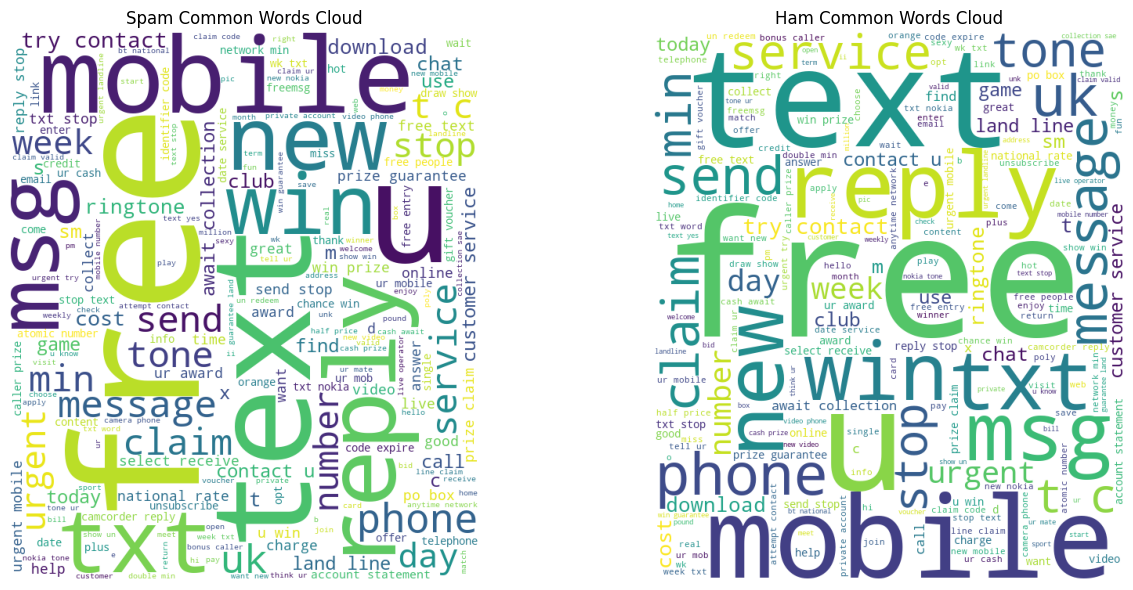

In [19]:
# Visualize the common words without stop words.
# ===================
# import the wordcloud lib
from wordcloud import WordCloud

# Create the wordcloud visual for both spam and ham
# ======================
# create data with spam only
spam_text = " ".join(sms_aug[sms_aug['label'] == 1]['clean_message'])


# create data with ham only
ham_text = " ".join(sms_aug[sms_aug['label'] == 0]['clean_message'])

# create wordcloud charts for each
spam_wc = WordCloud(width = 600, height=700, 
                    background_color='white').generate(spam_text)
ham_wc = WordCloud(width=600, height=700,
                    background_color='white').generate(spam_text)

# Create subplots
plt.figure(figsize=(14, 6), facecolor = None)

plt.subplot(1, 2, 1)
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam Common Words Cloud")

plt.subplot(1, 2, 2)
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham Common Words Cloud")

plt.tight_layout() 
plt.show()

From the word cloud we can indeed see the common words found in spam messages such as award, customer, win, free and so on.

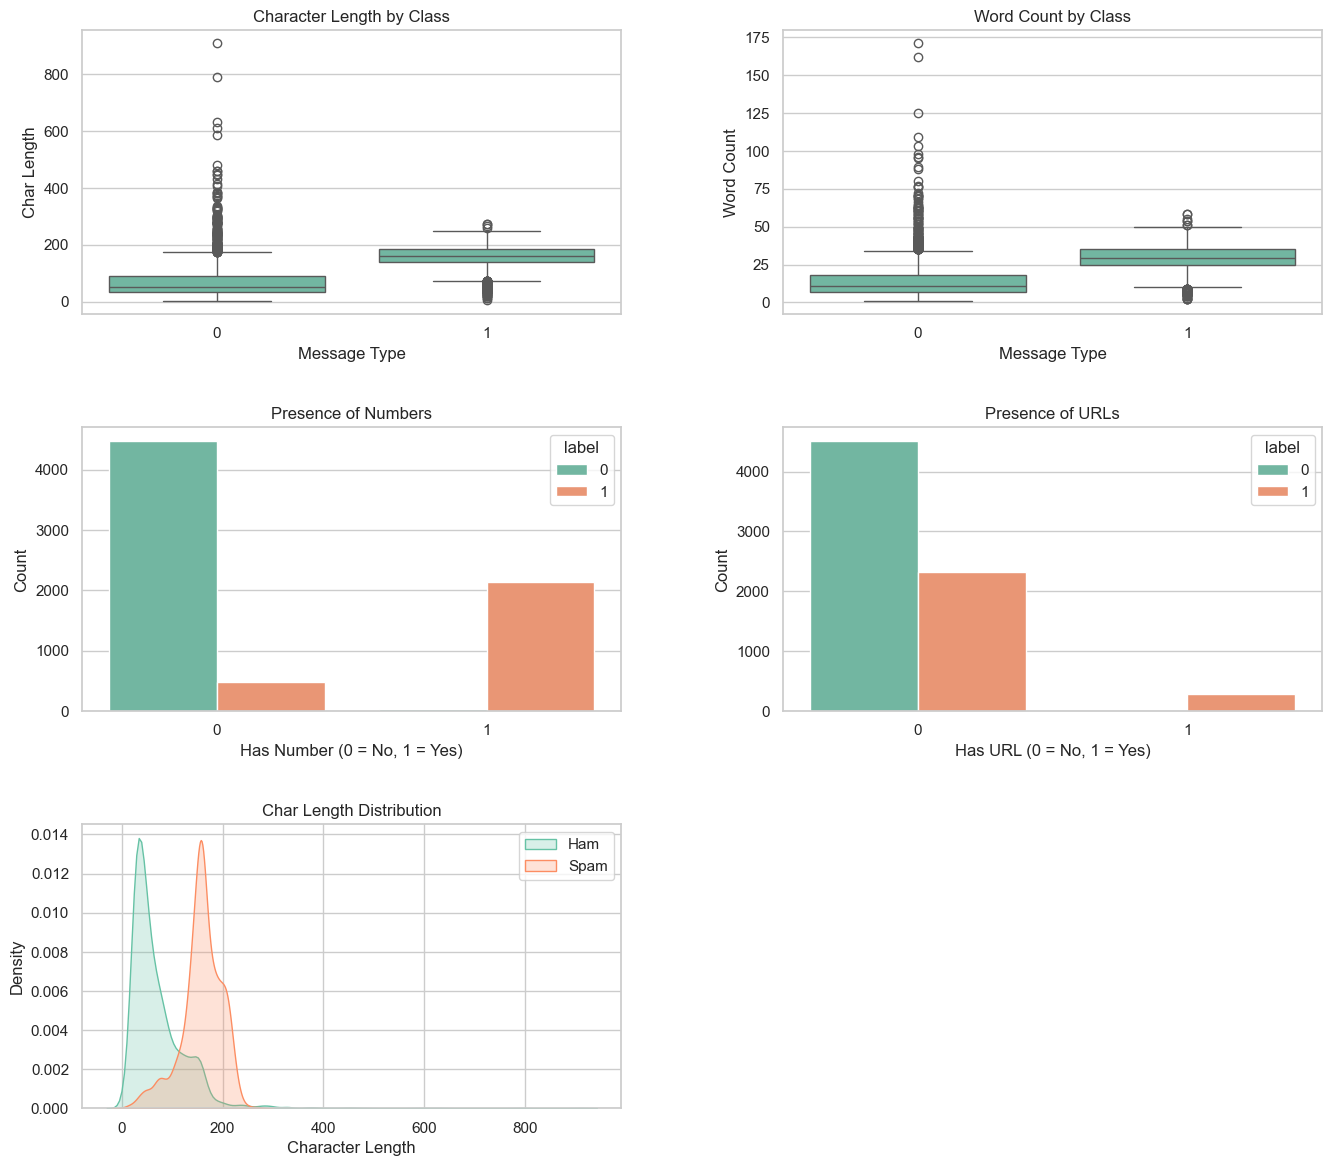

In [ ]:
# visualise the data with the created features
#=============================


# Theme + palette
sns.set_theme(style="whitegrid", palette="pastel")
sns.set_palette("Set2")

# Create figure with 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Character Length
sns.boxplot(data=sms_aug, x='label', y='char_length', ax=axes[0, 0])
axes[0, 0].set_title('Character Length by Class')
axes[0, 0].set_xlabel('Message Type')
axes[0, 0].set_ylabel('Char Length')

# 2. Word Count
sns.boxplot(data=sms_aug, x='label', y='word_count', ax=axes[0, 1])
axes[0, 1].set_title('Word Count by Class')
axes[0, 1].set_xlabel('Message Type')
axes[0, 1].set_ylabel('Word Count')

# 3. Has Number
sns.countplot(data=sms_aug, x='has_number', hue='label', ax=axes[1, 0])
axes[1, 0].set_title('Presence of Numbers')
axes[1, 0].set_xlabel('Has Number (0 = No, 1 = Yes)')
axes[1, 0].set_ylabel('Count')

# 4. Has URL
sns.countplot(data=sms_aug, x='has_url', hue='label', ax=axes[1, 1])
axes[1, 1].set_title('Presence of URLs')
axes[1, 1].set_xlabel('Has URL (0 = No, 1 = Yes)')
axes[1, 1].set_ylabel('Count')

# 5. Char Length Distribution (KDE)
sns.kdeplot(
    data=sms_aug[sms_aug['label'] == 0],
    x='char_length',
    label='Ham',
    fill=True,
    ax=axes[2, 0]
)
sns.kdeplot(
    data=sms_aug[sms_aug['label'] == 1],
    x='char_length',
    label='Spam',
    fill=True,
    ax=axes[2, 0]
)
axes[2, 0].set_title('Char Length Distribution')
axes[2, 0].set_xlabel('Character Length')
axes[2, 0].legend()

# 6. Remove last empty subplot (clean look)
fig.delaxes(axes[2, 1])

# Adjust spacing (key improvement)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.show()


#### insights from the visuals
* Character length: ham messages have shorter lengths. Spam is generally longer with many long messages due to more persuation, instructions, and urgency.
* Word Count: ham has fewer words (more natural chat). Spam has more words, different content and communication style.
* Presence of Numbers: has has no numbers at all. Most spam messages have numbers -> Spam messages rely heavily on numbers.
* Presence of URL's: Ham messages almost have no URL's. A few spam messages have url's.
* Character length Distribution: Ham peaks at low length, Spam at lower length. There's an overlap in the middle which might affect the models (Overlap: this is where we find slightly longer ham messages and short spam messages, affecting the confidence to train a model on the message length.)


### 7. Vectorization

In [23]:
# instantiate the vectorizer
vectorizer = CountVectorizer()

# Define the feature and the target
X = sms_aug[['clean_message', 'char_length', 'word_count', 'has_number', 'has_url']]
Y = sms_aug['label']

# Split into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3,
                                                    random_state=42, stratify = Y)

# Preprocess the pipeline
text_features = 'clean_message'
numeric_features = ['char_length', 'word_count', 'has_number', 'has_url']

preprocessor = ColumnTransformer(transformers = [
    ('text', TfidfVectorizer(max_features=3000), text_features),
    ('num', StandardScaler(), numeric_features)
])


# two functions to print the model metrics
def training_scores(y_test, y_pred):
    acc = round(accuracy_score(y_test, y_pred), 3)
    f1 = round(f1_score(y_test, y_pred), 3)
    cr = classification_report(y_test, y_pred)
    print(f'Training Scores: Accuracy={acc}')
    print("\n", "The classification report on Training set", "\n", cr)

def validation_scores(y_test, y_pred):
    acc = round(accuracy_score(y_test, y_pred), 3)
    f1 = round(f1_score(y_test, y_pred), 3)
    cr = classification_report(y_test, y_pred)
    print(f'Validation Scores: Accuracy={acc}')
    print("\n", "The classification report on Test set", "\n", cr)


### 8. Model Training and Evaluation

Being aware of the class imbalance we discovered during data analysis, we will only train models that support the class weight parameter. This parameter lets the model know which feature it needs to pay attention to, thus in this case we let the model know that mistakes on spam(minority class) are more costly than mistakes on ham.
The chosen models are Logistic regression, Linear SVM, and Random forest.

In [24]:
#pipeline for the lr model
lrm = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))])

# Train the Logistic Regression model and predict
lrm.fit(X_train, y_train)
# predictions
y_train_pred = lrm.predict(X_train)
y_pred = lrm.predict(X_test)
print("Evaluation Metrics For the Logistic Regression Model", "\n")
# Call the functions to evaluate the model on the training and test sets
training_scores(y_train, y_train_pred)
validation_scores(y_test, y_pred)

Evaluation Metrics For the Logistic Regression Model 

Training Scores: Accuracy=0.973

 The classification report on Training set 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      3161
           1       0.97      0.96      0.96      1828

    accuracy                           0.97      4989
   macro avg       0.97      0.97      0.97      4989
weighted avg       0.97      0.97      0.97      4989

Validation Scores: Accuracy=0.967

 The classification report on Test set 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1355
           1       0.98      0.93      0.95       784

    accuracy                           0.97      2139
   macro avg       0.97      0.96      0.96      2139
weighted avg       0.97      0.97      0.97      2139



Since we had a minority class inn the data and we specifically let the model know which feature not to make mistakes on, we will be evaluating the models based on this class, i.e.,:
    
    * Precision → “When I predict spam, how often am I right?”
    * Recall → “How many spam messages did I catch?”

The model scored higher during training and a bit lower during testing with respect to the two metrics. There's no big drop in the scores, so the model is not overfitting in any meaningful way.

In [25]:
# pipeline
l_svm =  Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced',max_iter=2000))])

# train the lsvm model
l_svm.fit(X_train, y_train)
# predict
y_train_pred = l_svm.predict(X_train)
y_test_pred = l_svm.predict(X_test)
#evaluate
training_scores(y_train, y_train_pred)
validation_scores(y_test, y_pred)


Training Scores: Accuracy=0.998

 The classification report on Training set 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3161
           1       1.00      1.00      1.00      1828

    accuracy                           1.00      4989
   macro avg       1.00      1.00      1.00      4989
weighted avg       1.00      1.00      1.00      4989

Validation Scores: Accuracy=0.967

 The classification report on Test set 
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1355
           1       0.98      0.93      0.95       784

    accuracy                           0.97      2139
   macro avg       0.97      0.96      0.96      2139
weighted avg       0.97      0.97      0.97      2139



The linear svm model shows perfect training performance and a noticeable drop on the test data, technically it is overfitting. Tuning the parameters by introducing regularization may improve the performance(e.g., pass "c=0.5" in the model parameters), and our confidence in the model.

In [26]:
# Training a Random Forest Classifier
rfc = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', RandomForestClassifier(n_estimators=100,
                                                             class_weight='balanced',
                                                             max_depth=None))])
rfc.fit(X_train, y_train)
y_train_pred = rfc.predict(X_train)
y_pred = rfc.predict(X_test)
print("Evaluation Metrics For the RandomForestClassifier Model")
# evaluate the model on the training and test sets
training_scores(y_train, y_train_pred)
validation_scores(y_test, y_pred)

Evaluation Metrics For the RandomForestClassifier Model
Training Scores: Accuracy=1.0

 The classification report on Training set 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3161
           1       1.00      1.00      1.00      1828

    accuracy                           1.00      4989
   macro avg       1.00      1.00      1.00      4989
weighted avg       1.00      1.00      1.00      4989

Validation Scores: Accuracy=0.987

 The classification report on Test set 
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1355
           1       0.99      0.97      0.98       784

    accuracy                           0.99      2139
   macro avg       0.99      0.98      0.99      2139
weighted avg       0.99      0.99      0.99      2139



same about linear svm applies to this model: is overfitting by a small margin, with a very strong test performance (accuracy ~0.99).

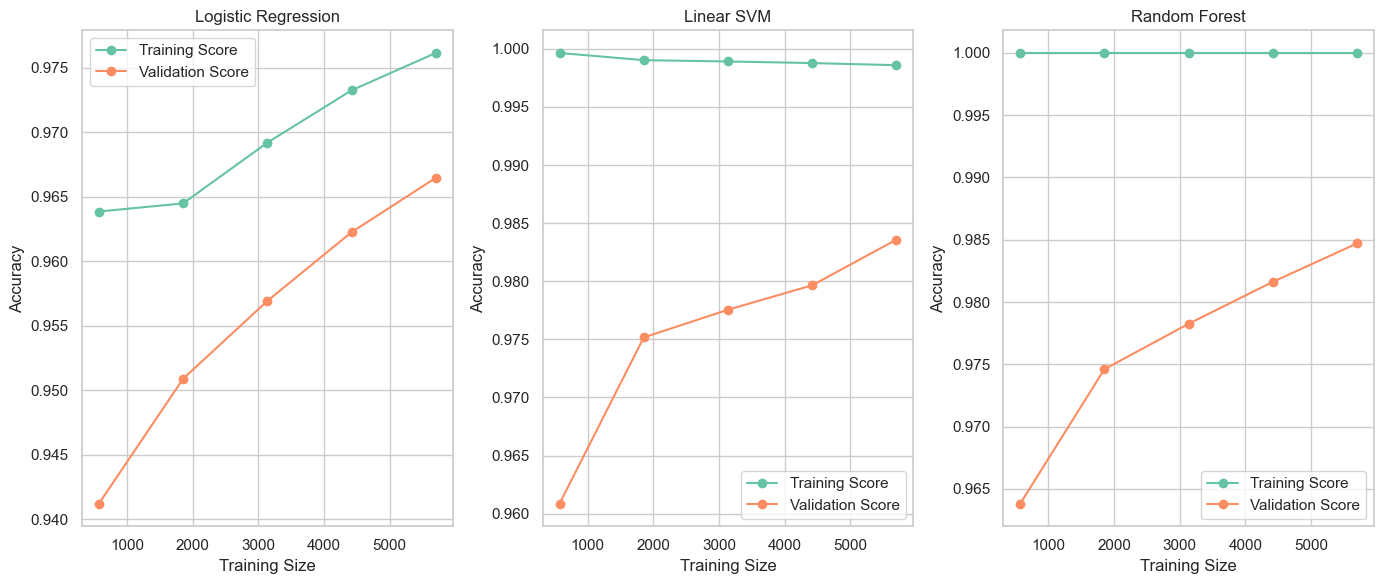

In [28]:
# Plot the learning curves to prove the performance visually
def plot_learning_curve(model, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation Score')

    plt.title(title)
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

# plot the learning curves
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plot_learning_curve(lrm, "Logistic Regression", X, Y)

plt.subplot(1, 3, 2)
plot_learning_curve(l_svm, "Linear SVM", X, Y)

plt.subplot(1, 3, 3)
plot_learning_curve(rfc, "Random Forest", X, Y)

plt.tight_layout()
plt.show()

### Thank you.
